## Plot disease distributon and event boxplots (Fig.2)

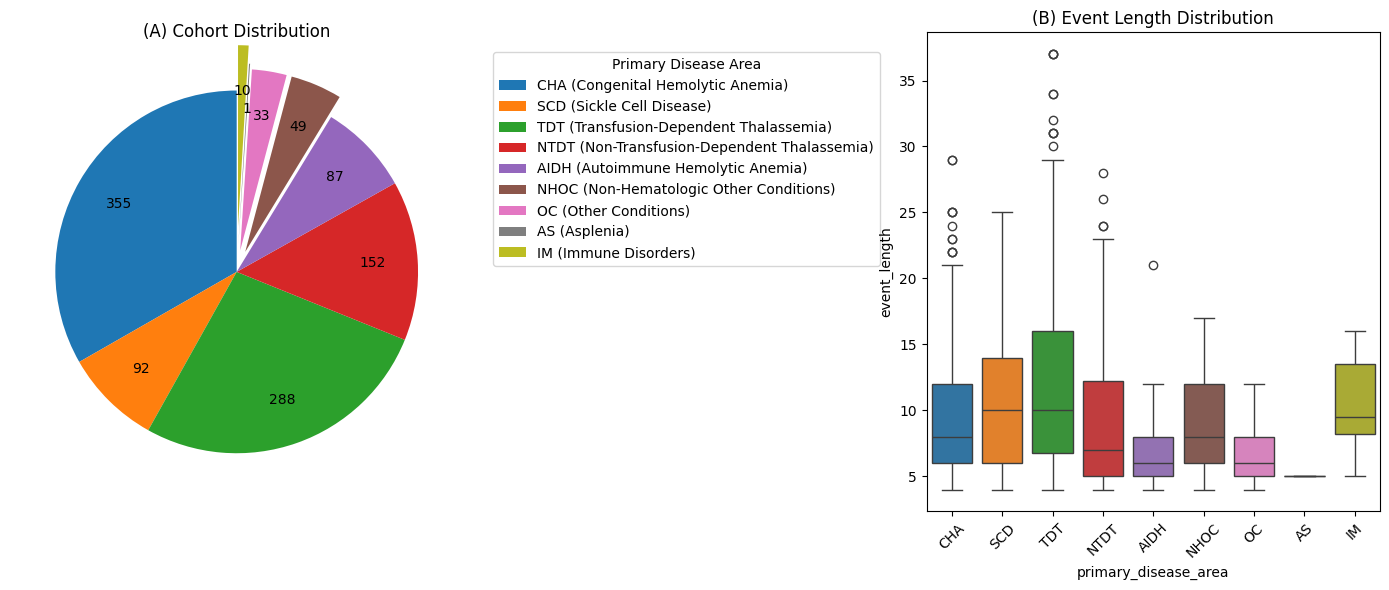

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

results_dir = "results_rev2"
label_order = ['CHA','SCD','TDT','NTDT','AIDH','NHOC','OC','AS','IM']
label_desc = {
    'CHA': 'Congenital Hemolytic Anemia',
    'SCD': 'Sickle Cell Disease',
    'TDT': 'Transfusion-Dependent Thalassemia',
    'NTDT': 'Non-Transfusion-Dependent Thalassemia',
    'AIDH': 'Autoimmune Hemolytic Anemia',
    'NHOC': 'Non-Hematologic Other Conditions',
    'OC': 'Other Conditions',
    'AS': 'Asplenia',
    'IM': 'Immune Disorders'
}

palette = sns.color_palette("tab10", len(label_order))
palette_dict = dict(zip(label_order, palette))

df = pd.read_json(f"dataset_tutti_5_flwup_from_notebook_EN.json").set_index("id")
groupname = "ALL"
selected_ids = pd.read_csv(f"{groupname}_index.csv", header=None).values.ravel()
df = df.loc[selected_ids]
df['event_length'] = df['events'].apply(len)
counts = df['primary_disease_area'].value_counts()
mapping = {i: label for i, label in enumerate(label_order)}
df['primary_disease_area'] = df['primary_disease_area'].map(mapping)
counts = df['primary_disease_area'].value_counts().reindex(label_order).fillna(0)

values = counts.values
labels = counts.index

# 🔥 explode più forte per classi piccole
explode = []
for l, v in zip(labels, values):
    if l in ['IM']:
        explode.append(0.25)   # molto separati
    elif l in ['AS']:
        explode.append(0.15)   # molto separati
    elif v < np.percentile(values, 40):
        explode.append(0.12)
    else:
        explode.append(0)

# solo valori assoluti (più piccoli e leggibili)
def autopct_abs(pct):
    total = np.sum(values)
    val = int(round(pct * total / 100.0))
    return f'{val}' if val > 0 else ''

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------- PIE ----------------
wedges, texts, autotexts = axes[0].pie(
    values,
    labels=None,  # 🔥 niente label interne
    colors=[palette_dict[l] for l in labels],
    explode=explode,
    autopct=autopct_abs,
    pctdistance=0.75,
    startangle=90
)

axes[0].set_title("(A) Cohort Distribution")

legend_labels = [f"{k} ({label_desc[k]})" for k in labels]
axes[0].legend(
    wedges,
    legend_labels,
    title="Primary Disease Area",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# ---------------- BOXPLOT ----------------
sns.boxplot(
    data=df,
    x='primary_disease_area',
    y='event_length',
    order=label_order,
    hue='primary_disease_area',
    palette=palette_dict,
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("(B) Event Length Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig(f"{results_dir}/Fig2.png", dpi=300, bbox_inches='tight')

## 5-iterated CV measures

In [20]:
import pandas as pd
import numpy as np
precision = 3
metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc']
metrics_data_err = {}
labels = ["ALL", "NTDT+TDT"]
xlabels = ["ALL", "NTDT+TDT"]
methods = ["STATIC", "BINARY", "DOME", "LSTM", "tLSTM", "GRU", "GRU-D", "RETAIN", "BEHRT", "Dipole"]
allowed_metrics = ['AUC', 'MCC', 'Recall', 'Prec']
for m in metrics:
    res = {}
    for g in ['ALL', 'NTDT+TDT']:
        df = pd.read_csv(f"results_rev2/resdata_5iter__{m}_{g}.csv", index_col=0)
        res[g] = {k:[np.mean(np.array(list(v.values()))), np.std(np.array(list(v.values())))] for k,v in df.to_dict().items()}
    metrics_data_err[m] = res
metrics_data_err

{'AUC': {'ALL': {'STATIC': [0.8269258067715503, 0.04063606544323585],
   'BINARY': [0.8390600166127372, 0.04112645094143848],
   'DOME': [0.8474929333878827, 0.03879358856354173],
   'LSTM': [0.7926993218531879, 0.0507211760950617],
   'tLSTM': [0.7807679826682039, 0.0449941507438619],
   'GRU': [0.7605203258080114, 0.052899834260237505],
   'GRU-D': [0.8178803108069574, 0.03989145757091001],
   'BEHRT': [0.7908931050941597, 0.0566525481243053],
   'RETAIN': [0.7687948636887714, 0.046299739809156644],
   'Dipole': [0.7811530355438191, 0.04995216836862943]},
  'NTDT+TDT': {'STATIC': [0.8466499503968253, 0.05189773985617669],
   'BINARY': [0.8934442956349206, 0.05036009527456428],
   'DOME': [0.9006474950396824, 0.046996708900911746],
   'LSTM': [0.8475283978174604, 0.04194789139274852],
   'tLSTM': [0.8036980902777777, 0.05808148119564542],
   'GRU': [0.7986743551587303, 0.04885690316277066],
   'GRU-D': [0.8630155257936509, 0.045127185712042224],
   'BEHRT': [0.8277711805555557, 0.0653

## One CV measures (skip this!)

In [ ]:
if False:   # Not used anymore (use iterated features above)
    import pandas as pd
    precision = 3
    r1 = pd.read_csv("results_ina_ALL.csv", index_col=0)
    r2 = pd.read_csv("results_ina_NTDT+TDT.csv", index_col=0)
    xlabels = ["All", "Thalassemic"]
    labels = ["All", "Thalassemic"]
    methods = ["STATIC", "STATIC+BINARY", "STATIC+DOME", "STATIC+LSTM", "STATIC+tLSTM", "STATIC+GRU", "STATIC+GRU-D", "STATIC+RETAIN", "STATIC+BEHRT", "STATIC+Dipole"]
    allowed_metrics = ['AUC', 'MCC', 'Recall', 'Prec']
    metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc']
    for m in metrics:
        r1[m] = r1.apply(lambda x: [round(x[f'{m} mean'],precision),round(x[f'{m} std'],precision)], axis=1)
        r2[m] = r2.apply(lambda x: [round(x[f'{m} mean'],precision),round(x[f'{m} std'],precision)], axis=1)
    results1 = r1[metrics].to_dict()
    results2 = r2[metrics].to_dict()
    dict1 = {key : {"All": results1[key]} for key,val in results1.items()}
    dict2 = {key : {"Thalassemic": results2[key]} for key,val in results2.items()}
    metrics_data_err = {key : dict1[key] | dict2[key] for key,_ in dict1.items()}
    metrics_data_err

{'AUC': {'All': {'STATIC': [0.852, 0.029],
   'STATIC+BINARY': [0.848, 0.05],
   'STATIC+DOME': [0.858, 0.036],
   'STATIC+LSTM': [0.805, 0.039],
   'STATIC+tLSTM': [0.787, 0.064],
   'STATIC+GRU': [0.756, 0.053],
   'STATIC+GRU-D': [0.822, 0.052],
   'STATIC+BEHRT': [0.781, 0.069],
   'STATIC+RETAIN': [0.773, 0.054],
   'STATIC+Dipole': [0.788, 0.055]},
  'Thalassemic': {'STATIC': [0.856, 0.038],
   'STATIC+BINARY': [0.883, 0.049],
   'STATIC+DOME': [0.896, 0.042],
   'STATIC+LSTM': [0.85, 0.034],
   'STATIC+tLSTM': [0.841, 0.054],
   'STATIC+GRU': [0.819, 0.063],
   'STATIC+GRU-D': [0.867, 0.029],
   'STATIC+BEHRT': [0.837, 0.05],
   'STATIC+RETAIN': [0.827, 0.023],
   'STATIC+Dipole': [0.837, 0.072]}},
 'F1': {'All': {'STATIC': [0.641, 0.048],
   'STATIC+BINARY': [0.683, 0.061],
   'STATIC+DOME': [0.714, 0.048],
   'STATIC+LSTM': [0.638, 0.061],
   'STATIC+tLSTM': [0.592, 0.089],
   'STATIC+GRU': [0.558, 0.087],
   'STATIC+GRU-D': [0.674, 0.069],
   'STATIC+BEHRT': [0.608, 0.095],
 

## Plot measures (Fig.3)

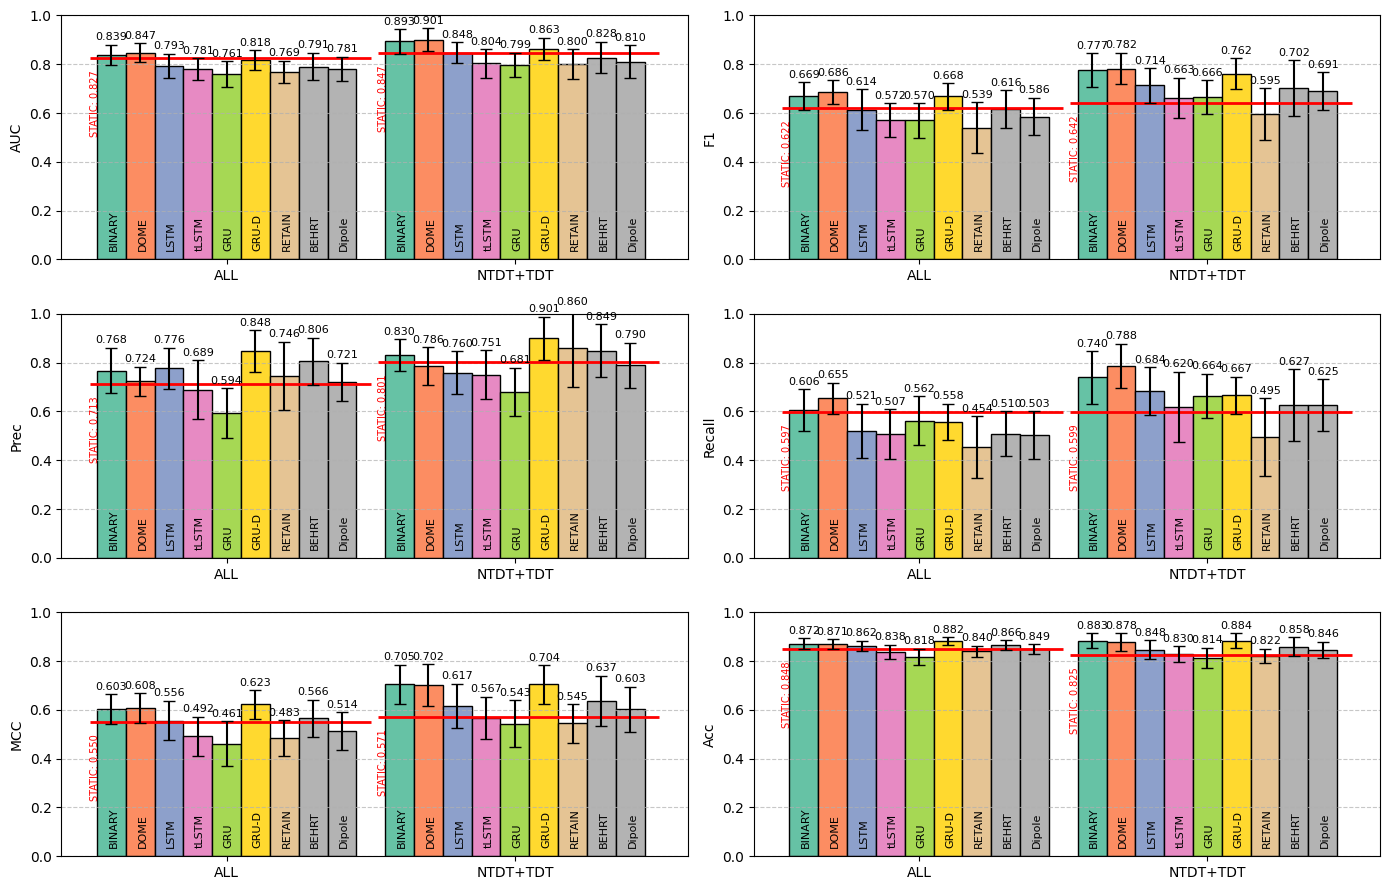

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import math

allowed_metrics = metrics

# 🎨 Tavolozza colori distinta
colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
x = np.arange(len(labels)) * 0.2
width = 0.02
fontsize = 8

# 👉 NUOVA GRIGLIA: 2 subplot per riga
n_metrics = len(metrics)
n_cols = 2
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=False)
axes = axes.flatten()  # 🔑 fondamentale

for ax, metric in zip(axes, allowed_metrics):
    cnt = 0
    for i, (method, color) in enumerate(zip(methods, colors)):
        means = [metrics_data_err[metric][pat][method][0] for pat in labels]
        errs = [metrics_data_err[metric][pat][method][1] for pat in labels]

        group_width = width * len(methods)
        if method == "STATIC":
            for j, gm in enumerate(means):
                ax.hlines(
                    y=gm,
                    xmin=x[j] - group_width/2 + 0.005,
                    xmax=x[j] + group_width/2,
                    colors='red',
                    linestyles='-',
                    linewidth=2
                )
                ax.text(
                    x[j] - group_width/2  +0.005,
                    gm - 0.05,
                    f"STATIC: {gm:.3f}",
                    ha='left',
                    va='top',
                    fontsize=7,
                    rotation=90, 
                    color='red'
                )
            continue
        
        bar_positions = x + i*width - (width*len(methods)/2)
        bars = ax.bar(
            bar_positions,
            means,
            width,
            yerr=errs,
            capsize=4,
            color=color,
            edgecolor='black'
        )

        # 📝 Etichette metodo alla base
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2 + 0.005,
                0.033,
                method.removeprefix('STATIC+'),
                ha='right',
                va='bottom',
                rotation=90,
                fontsize=fontsize
            )
            cnt += 1

        # 📈 Valori sopra ogni barra
        for j, (bar, val) in enumerate(zip(bars, means)):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + errs[j] + 0.01,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                fontsize=fontsize,
            )

    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# 👉 Rimuove subplot vuoti (se numero dispari di metriche)
for i in range(len(allowed_metrics), len(axes)):
    fig.delaxes(axes[i])

fig.tight_layout(rect=[0, 0, 1, 1])
#fig.savefig("results_emb+lgbm_1133.png", dpi=300, bbox_inches='tight')

## Tables from results (Tables 9-10)

In [8]:
df


,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
0,0.863636,0.909091,0.897727,0.863636,0.886364,0.875000,0.920455,0.875000,0.863636,0.886364
1,0.761364,0.852273,0.784091,0.818182,0.829545,0.806818,0.875000,0.795455,0.818182,0.875000
2,0.795455,0.852273,0.829545,0.829545,0.795455,0.829545,0.886364,0.795455,0.795455,0.852273
3,0.840909,0.897727,0.920455,0.829545,0.829545,0.795455,0.852273,0.863636,0.818182,0.829545
4,0.829545,0.909091,0.920455,0.886364,0.897727,0.875000,0.954545,0.886364,0.852273,0.931818
5,0.897727,0.909091,0.886364,0.806818,0.818182,0.818182,0.863636,0.852273,0.840909,0.840909
6,0.806818,0.897727,0.875000,0.852273,0.840909,0.750000,0.909091,0.897727,0.795455,0.863636
7,0.795455,0.840909,0.829545,0.852273,0.761364,0.818182,0.852273,0.840909,0.795455,0.863636
8,0.840909,0.943182,0.931818,0.920455,0.863636,0.886364,0.920455,0.875000,0.852273,0.875000
9,0.852273,0.875000,0.886364,0.818182,0.840909,0.784091,0.863636,0.909091,0.795455,0.863636


In [10]:
import pandas as pd
import numpy as np
metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'CM']
dfs = {}
for p in metrics:
    dfs[p] = pd.read_csv(f"resdata_{p}_NTDT+TDT.csv", index_col=0)
    for m in dfs[p].columns:
        print(f"{m},", end='')
        if p == "CM":
                cm = dfs[p][m].apply(lambda x: np.array(eval(x))).sum() / 5
                print(f"{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + "{N}{P}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}}")
        else:
            None

STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole,STATIC,{289.4}{27.6}{49.4}{73.6}{N}{P}{317.0}{123.0}
BINARY,{297.6}{19.4}{32.0}{91.0}{N}{P}{317.0}{123.0}
DOME,{289.4}{27.6}{26.2}{96.8}{N}{P}{317.0}{123.0}
LSTM,{288.8}{28.2}{38.8}{84.2}{N}{P}{317.0}{123.0}
tLSTM,{288.8}{28.2}{46.8}{76.2}{N}{P}{317.0}{123.0}
GRU,{276.6}{40.4}{41.4}{81.6}{N}{P}{317.0}{123.0}
GRU-D,{307.0}{10.0}{41.0}{82.0}{N}{P}{317.0}{123.0}
BEHRT,{300.6}{16.4}{46.0}{77.0}{N}{P}{317.0}{123.0}
RETAIN,{301.0}{16.0}{62.2}{60.8}{N}{P}{317.0}{123.0}
Dipole,{295.4}{21.6}{46.2}{76.8}{N}{P}{317.0}{123.0}


In [11]:
for g in ['ALL','NTDT+TDT']:
    for p in metrics:
        print(f"& {p} ", end='')
        dfs[p] = pd.read_csv(f"resdata_{p}_{g}.csv", index_col=0)
    print("\\\\")
    for m in dfs[p].columns:
        print(f"{m} & ", end='')
        for p in metrics:
            if p == "CM":
                    cm = dfs[p][m].apply(lambda x: np.array(eval(x))).sum() / 5
                    print(f"\\cm{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + "{N}{P}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}} \\\\")
            else:
                print(f"{dfs[p][m].mean():.3f}$\pm${dfs[p][m].std():.3f} & ", end="")
    print()

& AUC & F1 & Prec & Recall & MCC & Acc & CM \\
STATIC & 0.827$\pm$0.041 & 0.622$\pm$0.069 & 0.713$\pm$0.148 & 0.597$\pm$0.140 & 0.550$\pm$0.055 & 0.848$\pm$0.024 & \cm{767.8}{69.2}{92.8}{137.2}{N}{P}{837.0}{230.0} \\
BINARY & 0.839$\pm$0.042 & 0.669$\pm$0.057 & 0.768$\pm$0.095 & 0.606$\pm$0.087 & 0.603$\pm$0.063 & 0.872$\pm$0.022 & \cm{791.0}{46.0}{90.6}{139.4}{N}{P}{837.0}{230.0} \\
DOME & 0.847$\pm$0.040 & 0.686$\pm$0.050 & 0.724$\pm$0.061 & 0.655$\pm$0.064 & 0.608$\pm$0.062 & 0.871$\pm$0.020 & \cm{778.8}{58.2}{79.4}{150.6}{N}{P}{837.0}{230.0} \\
LSTM & 0.793$\pm$0.052 & 0.614$\pm$0.085 & 0.776$\pm$0.087 & 0.521$\pm$0.113 & 0.556$\pm$0.083 & 0.862$\pm$0.022 & \cm{800.4}{36.6}{110.2}{119.8}{N}{P}{837.0}{230.0} \\
tLSTM & 0.781$\pm$0.046 & 0.572$\pm$0.070 & 0.689$\pm$0.123 & 0.507$\pm$0.103 & 0.492$\pm$0.083 & 0.838$\pm$0.030 & \cm{777.4}{59.6}{113.4}{116.6}{N}{P}{837.0}{230.0} \\
GRU & 0.761$\pm$0.054 & 0.570$\pm$0.073 & 0.594$\pm$0.103 & 0.562$\pm$0.103 & 0.461$\pm$0.094 & 0.818$\pm$

## Plot subgroups calibration / length boxplots (Fig. 5)

/tmp/ipykernel_210892/1838862262.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_210892/1838862262.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_210892/1838862262.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


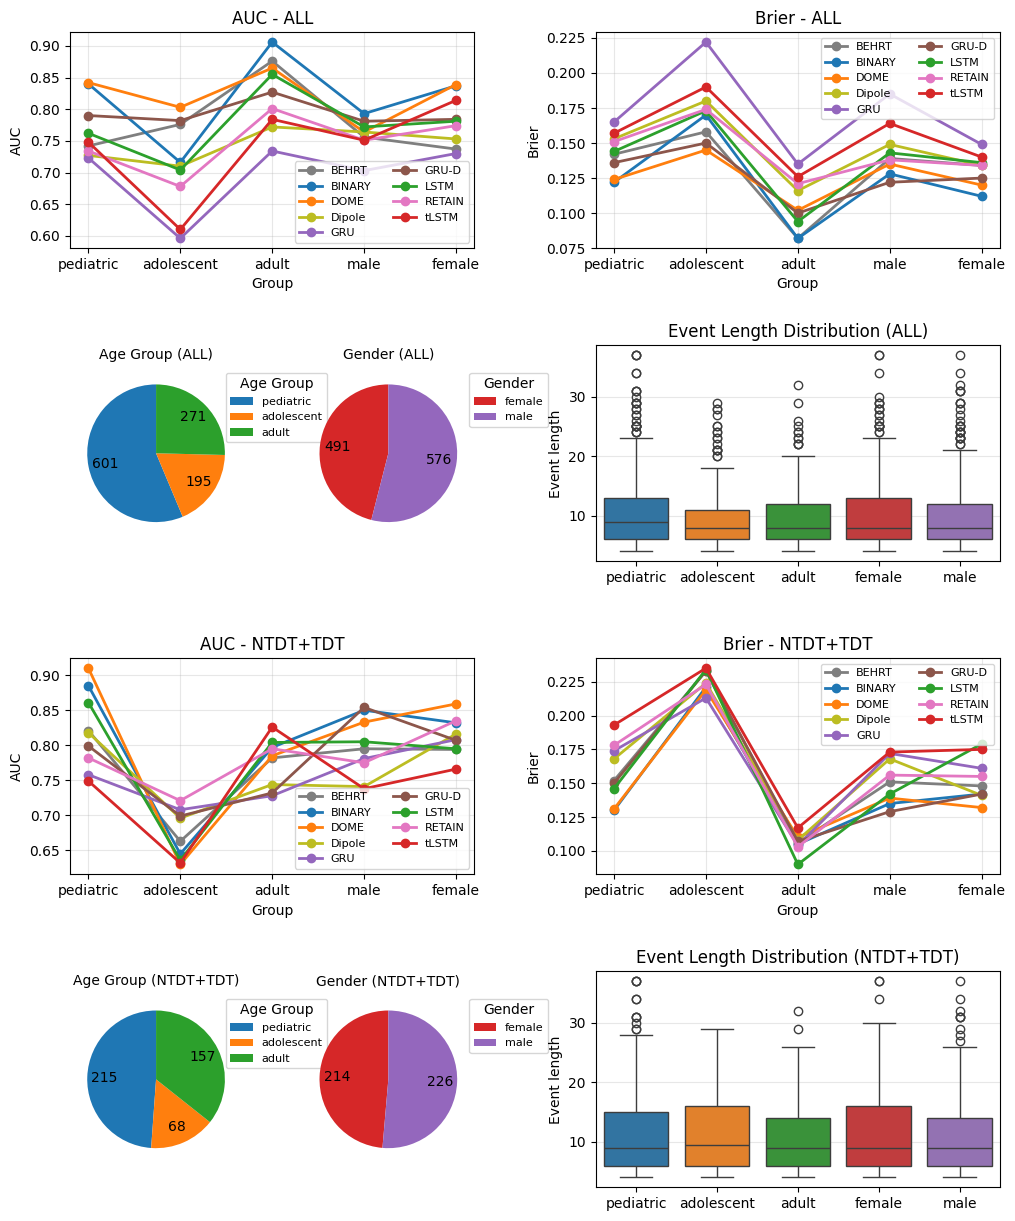

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# CONFIG
# =========================================================
precision = 3
lang = 'EN'
dataset_path = f"dataset_tutti_5_flwup_from_notebook_{lang}.json"
results_dir = "results_rev2"

subgroups = ['male', 'female', 'pediatric', 'adolescent', 'adult']
group_order = ['pediatric', 'adolescent', 'adult', 'male', 'female']

methods = ["BINARY", "DOME", "LSTM", "tLSTM", "GRU", "GRU-D", "RETAIN", "BEHRT", "Dipole"]
columns = [f"STATIC+{m}" for m in methods]
metrics_for_files = ['AUC']
metrics_to_plot = ['AUC', 'Brier']

age_order = ['pediatric', 'adolescent', 'adult']
gender_order = ['female', 'male']
box_order = age_order + gender_order

palette_dict = {
    'pediatric': sns.color_palette("tab10")[0],
    'adolescent': sns.color_palette("tab10")[1],
    'adult': sns.color_palette("tab10")[2],
    'female': sns.color_palette("tab10")[3],
    'male': sns.color_palette("tab10")[4],
}

method_palette = dict(zip(methods, sns.color_palette("tab10", len(methods))))

# =========================================================
# HELPERS - METRICS
# =========================================================
def load_metrics_dict(prefix):
    dicts = []

    for g in subgroups:
        r = pd.read_csv(f"{results_dir}/resdata_{prefix}{g}.csv", index_col=0)
        r = r.loc[columns].copy()

        for m in metrics_for_files:
            r[m] = r[f'{m} mean'].round(precision)

        r['Brier'] = r['Brier'].round(precision)
        results = r[['AUC', 'Brier']].to_dict()

        dicts += [{key: {g: results[key]} for key in results.keys()}]

    metrics_data = {}
    for d in dicts:
        for k, v in d.items():
            if metrics_data.get(k) is None:
                metrics_data[k] = []
            if v not in metrics_data[k]:
                metrics_data[k].append(v)

    return metrics_data


def metric_dict_to_df(metric_block, metric_name, cohort_name):
    rows = []

    for item in metric_block:
        group = list(item.keys())[0]
        method_vals = item[group]

        for method, value in method_vals.items():
            rows.append({
                'cohort': cohort_name,
                'metric': metric_name,
                'group': group,
                'method': method.replace('STATIC+', ''),
                'value': value
            })

    return pd.DataFrame(rows)


def build_plot_df(metrics_data_err_all, metrics_data_err_ntdt):
    dfs = []

    for metric in metrics_to_plot:
        dfs.append(metric_dict_to_df(metrics_data_err_all[metric], metric, 'ALL'))
        dfs.append(metric_dict_to_df(metrics_data_err_ntdt[metric], metric, 'NTDT+TDT'))

    df_plot = pd.concat(dfs, ignore_index=True)
    df_plot['group'] = pd.Categorical(df_plot['group'], categories=group_order, ordered=True)

    return df_plot.sort_values(['metric', 'cohort', 'group', 'method'])


# =========================================================
# HELPERS - DISTRIBUTIONS
# =========================================================
def load_and_prepare_base_df():
    df = pd.read_json(dataset_path).set_index("id").copy()

    df['event_length'] = df['events'].apply(len)

    df['age_group'] = df['age_group'].astype(float).map({
        0.0: 'pediatric',
        1.0: 'adolescent',
        2.0: 'adult'
    })

    gender_map = {
        1.0: 'female',
        0.0: 'male'
    }

    if pd.api.types.is_numeric_dtype(df['gender']):
        df['gender'] = df['gender'].astype(float).map(gender_map)
    else:
        df['gender'] = df['gender'].astype(str).str.strip().str.lower()

    df = df.dropna(subset=['age_group', 'gender', 'event_length'])
    return df


def get_cohort_df(df_all, cohort_name):
    selected_ids = pd.read_csv(f"{cohort_name}_index.csv", header=None).values.ravel()
    selected_ids = pd.Index(selected_ids)
    return df_all.loc[df_all.index.intersection(selected_ids)].copy()


def make_distribution_data(df):
    age_counts = df['age_group'].value_counts().reindex(age_order, fill_value=0)
    gender_counts = df['gender'].value_counts().reindex(gender_order, fill_value=0)

    box_df = pd.concat([
        df.loc[df['age_group'] == 'pediatric', ['event_length']].assign(group='pediatric'),
        df.loc[df['age_group'] == 'adolescent', ['event_length']].assign(group='adolescent'),
        df.loc[df['age_group'] == 'adult', ['event_length']].assign(group='adult'),
        df.loc[df['gender'] == 'female', ['event_length']].assign(group='female'),
        df.loc[df['gender'] == 'male', ['event_length']].assign(group='male'),
    ], ignore_index=True)

    return age_counts, gender_counts, box_df


def make_autopct(values):
    def autopct(pct):
        total = np.sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}' if val > 0 else ''
    return autopct


# =========================================================
# PLOT HELPERS
# =========================================================
def plot_metric_panel(ax, df_plot, cohort, metric):
    sub = df_plot[(df_plot['metric'] == metric) & (df_plot['cohort'] == cohort)].copy()

    pivot_df = sub.pivot_table(
        index='group',
        columns='method',
        values='value',
        aggfunc='mean'
    ).reindex(group_order)

    for method in pivot_df.columns:
        ax.plot(
            pivot_df.index,
            pivot_df[method],
            marker='o',
            linewidth=2,
            label=method,
            color=method_palette.get(method, None)
        )

    ax.set_title(f'{metric} - {cohort}')
    ax.set_xlabel('Group')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8, loc='best', ncol=2)

def plot_pie(ax, counts, title, legend_title):
    wedges, _, _ = ax.pie(
        counts.values,
        labels=None,
        colors=[palette_dict[k] for k in counts.index],
        autopct=make_autopct(counts.values),
        pctdistance=0.75,
        startangle=90
    )
    ax.set_title(title, fontsize=10)
    ax.legend(
        wedges,
        counts.index,
        title=legend_title,
        bbox_to_anchor=(1.2, 1.0),
        loc='upper center',
        fontsize=8
    )


def plot_box(ax, box_df, title):
    sns.boxplot(
        data=box_df,
        x='group',
        y='event_length',
        order=box_order,
        palette=palette_dict,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Event length")
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, axis='y', alpha=0.3)


# =========================================================
# LOAD DATA
# =========================================================
metrics_data_err_all = load_metrics_dict("ALL")
metrics_data_err_ntdt = load_metrics_dict("NTDT+TDT")
df_metrics_plot = build_plot_df(metrics_data_err_all, metrics_data_err_ntdt)

df_base = load_and_prepare_base_df()
df_all_cohort = get_cohort_df(df_base, "ALL")
df_ntdt_cohort = get_cohort_df(df_base, "NTDT+TDT")

age_counts_all, gender_counts_all, box_df_all = make_distribution_data(df_all_cohort)
age_counts_ntdt, gender_counts_ntdt, box_df_ntdt = make_distribution_data(df_ntdt_cohort)

# =========================================================
# FIGURA 4x2 con pie chart doppi nello stesso quadrante
# =========================================================
fig = plt.figure(figsize=(12, 15))
gs = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.3)

# Riga 1
ax_auc_all = fig.add_subplot(gs[0, 0])
ax_brier_all = fig.add_subplot(gs[0, 1])

# Riga 2
gs_pie_all = gs[1, 0].subgridspec(1, 2, wspace=0.35)
ax_age_all = fig.add_subplot(gs_pie_all[0, 0])
ax_gender_all = fig.add_subplot(gs_pie_all[0, 1])
ax_box_all = fig.add_subplot(gs[1, 1])

# Riga 3
ax_auc_ntdt = fig.add_subplot(gs[2, 0])
ax_brier_ntdt = fig.add_subplot(gs[2, 1])

# Riga 4
gs_pie_ntdt = gs[3, 0].subgridspec(1, 2, wspace=0.35)
ax_age_ntdt = fig.add_subplot(gs_pie_ntdt[0, 0])
ax_gender_ntdt = fig.add_subplot(gs_pie_ntdt[0, 1])
ax_box_ntdt = fig.add_subplot(gs[3, 1])

# ------------------ plots ------------------
plot_metric_panel(ax_auc_all, df_metrics_plot, 'ALL', 'AUC')
plot_metric_panel(ax_brier_all, df_metrics_plot, 'ALL', 'Brier')

plot_pie(ax_age_all, age_counts_all, 'Age Group (ALL)', 'Age Group')
plot_pie(ax_gender_all, gender_counts_all, 'Gender (ALL)', 'Gender')
plot_box(ax_box_all, box_df_all, 'Event Length Distribution (ALL)')

plot_metric_panel(ax_auc_ntdt, df_metrics_plot, 'NTDT+TDT', 'AUC')
plot_metric_panel(ax_brier_ntdt, df_metrics_plot, 'NTDT+TDT', 'Brier')

plot_pie(ax_age_ntdt, age_counts_ntdt, 'Age Group (NTDT+TDT)', 'Age Group')
plot_pie(ax_gender_ntdt, gender_counts_ntdt, 'Gender (NTDT+TDT)', 'Gender')
plot_box(ax_box_ntdt, box_df_ntdt, 'Event Length Distribution (NTDT+TDT)')

plt.tight_layout()
plt.show()
fig.savefig(f"results_rev2/Fig5.png", dpi=300, bbox_inches='tight')

## Fairness and Bias evaluation (Table 8)

In [19]:
import pandas as pd
import numpy as np


def compute_fairness_table(df):
    rows = []

    for metric in ['AUC', 'Brier']:
        for cohort in df['cohort'].unique():
            for method in df['method'].unique():

                sub = df[
                    (df['metric'] == metric) &
                    (df['cohort'] == cohort) &
                    (df['method'] == method)
                ].copy()

                if sub.empty:
                    continue

                values = sub['value'].values
                groups = sub['group'].values

                gap = np.max(values) - np.min(values)
                std = np.std(values)

                # Worst subgroup:
                # - AUC: worst = minimum value
                # - Brier: worst = maximum value
                if metric == 'AUC':
                    worst_idx = np.argmin(values)
                else:
                    worst_idx = np.argmax(values)

                worst_value = values[worst_idx]
                worst_group = groups[worst_idx]

                rows.append({
                    'Cohort': cohort,
                    'Metric': metric,
                    'Method': method,
                    'Gap': round(gap, 3),
                    'Std': round(std, 3),
                    'WorstValue': round(worst_value, 3),
                    'WorstGroup': str(worst_group)
                })

    return pd.DataFrame(rows)


def format_fairness_latex(df, top_k=None, add_rank=True, highlight_best_worst=True):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Output di compute_fairness_table
    top_k : int or None
        Se impostato, mostra solo i top_k modelli per ciascuna coppia (Metric, Cohort)
    add_rank : bool
        Se True, aggiunge colonna Rank
    highlight_best_worst : bool
        Se True, evidenzia anche il miglior worst-value
    """
    df = df.copy()
    latex_rows = []

    for (metric, cohort), subdf in df.groupby(['Metric', 'Cohort']):
        # ranking fairness: gap basso, poi std basso
        # tie-break sul worst value:
        # - AUC: higher worst is better
        # - Brier: lower worst is better
        if metric == 'AUC':
            subdf = subdf.sort_values(
                by=['Gap', 'Std', 'WorstValue'],
                ascending=[True, True, False]
            ).reset_index(drop=True)
        else:
            subdf = subdf.sort_values(
                by=['Gap', 'Std', 'WorstValue'],
                ascending=[True, True, True]
            ).reset_index(drop=True)

        subdf['Rank'] = np.arange(1, len(subdf) + 1)

        if top_k is not None:
            subdf = subdf.head(top_k)

        best_gap = subdf['Gap'].min()
        best_std = subdf['Std'].min()

        if metric == 'AUC':
            best_worst = subdf['WorstValue'].max()
        else:
            best_worst = subdf['WorstValue'].min()

        for _, row in subdf.iterrows():
            rank = row['Rank']
            method = row['Method']
            gap = row['Gap']
            std = row['Std']
            worst_value = row['WorstValue']
            worst_group = row['WorstGroup']

            gap_str = f"\\textbf{{{gap}}}" if gap == best_gap else f"{gap}"
            std_str = f"\\textbf{{{std}}}" if std == best_std else f"{std}"

            if highlight_best_worst:
                worst_value_str = f"\\textbf{{{worst_value}}}" if worst_value == best_worst else f"{worst_value}"
            else:
                worst_value_str = f"{worst_value}"

            if add_rank:
                latex_rows.append(
                    f"{cohort} & {metric} & {rank} & {method} & {gap_str} & {std_str} & {worst_value_str} & {worst_group} \\\\"
                )
            else:
                latex_rows.append(
                    f"{cohort} & {metric} & {method} & {gap_str} & {std_str} & {worst_value_str} & {worst_group} \\\\"
                )

    return "\n".join(latex_rows)


def build_fairness_latex_table(df, top_k=None, add_rank=True, highlight_best_worst=True):
    latex_body = format_fairness_latex(
        df,
        top_k=top_k,
        add_rank=add_rank,
        highlight_best_worst=highlight_best_worst
    )

    if add_rank:
        table = f"""
\\begin{{table}}[t]
\\centering
\\caption{{Fairness analysis across subgroups. Gap and standard deviation measure performance variability across demographic groups (lower is better). Worst-value reports the least favorable subgroup performance for each method, while Worst-group identifies the corresponding subgroup. Best values are highlighted in bold.}}
\\label{{tab:fairness}}
\\begin{{tabular}}{{llcccccc}}
\\toprule
Cohort & Metric & Rank & Method & Gap $\\downarrow$ & Std $\\downarrow$ & Worst-value & Worst-group \\\\
\\midrule
{latex_body}
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    else:
        table = f"""
\\begin{{table}}[t]
\\centering
\\caption{{Fairness analysis across subgroups. Gap and standard deviation measure performance variability across demographic groups (lower is better). Worst-value reports the least favorable subgroup performance for each method, while Worst-group identifies the corresponding subgroup. Best values are highlighted in bold.}}
\\label{{tab:fairness}}
\\begin{{tabular}}{{llccccccc}}
\\toprule
Cohort & Metric & Method & Gap $\\downarrow$ & Std $\\downarrow$ & Worst-value & Worst-group \\\\
\\midrule
{latex_body}
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    return table


# ESEMPIO DI USO
fairness_df = compute_fairness_table(df_metrics_plot)

latex_table = build_fairness_latex_table(
    fairness_df,
    top_k=5,
    add_rank=True,
    highlight_best_worst=True
)

print(latex_table)


\begin{table}[t]
\centering
\caption{Fairness analysis across subgroups. Gap and standard deviation measure performance variability across demographic groups (lower is better). Worst-value reports the least favorable subgroup performance for each method, while Worst-group identifies the corresponding subgroup. Best values are highlighted in bold.}
\label{tab:fairness}
\begin{tabular}{llcccccc}
\toprule
Cohort & Metric & Rank & Method & Gap $\downarrow$ & Std $\downarrow$ & Worst-value & Worst-group \\
\midrule
ALL & AUC & 1 & GRU-D & \textbf{0.046} & \textbf{0.017} & \textbf{0.781} & male \\
ALL & AUC & 2 & Dipole & 0.062 & 0.023 & 0.71 & adolescent \\
ALL & AUC & 3 & DOME & 0.101 & 0.035 & 0.764 & male \\
ALL & AUC & 4 & RETAIN & 0.123 & 0.041 & 0.678 & adolescent \\
ALL & AUC & 5 & GRU & 0.138 & 0.052 & 0.596 & adolescent \\
NTDT+TDT & AUC & 1 & GRU & \textbf{0.1} & \textbf{0.036} & 0.708 & adolescent \\
NTDT+TDT & AUC & 2 & RETAIN & 0.114 & 0.037 & \textbf{0.721} & adolescent \\
NT

## Plot Calibration on Thalassemic patients (Fig. 4)

In [15]:
import pickle
groupname = "NTDT+TDT"
methods = ["BINARY", "DOME", "LSTM", "tLSTM", "GRU", "GRU-D", "RETAIN", "BEHRT", "Dipole"]
with open(f"results_rev2/results_{groupname}.pkl", 'rb') as f:
    results = pickle.load(f)
prob_pred = {}
prob_true = {}
all_runs = {}
for m in methods:
    prob_pred[m] = results[m]['calibration_prob_pred']
    prob_true[m] = results[m]['calibration_prob_true']
    all_runs[m] = (results[m]['y_true_oof'], results[m]['y_prob_oof'])

### draw calibration curves + probability histograms

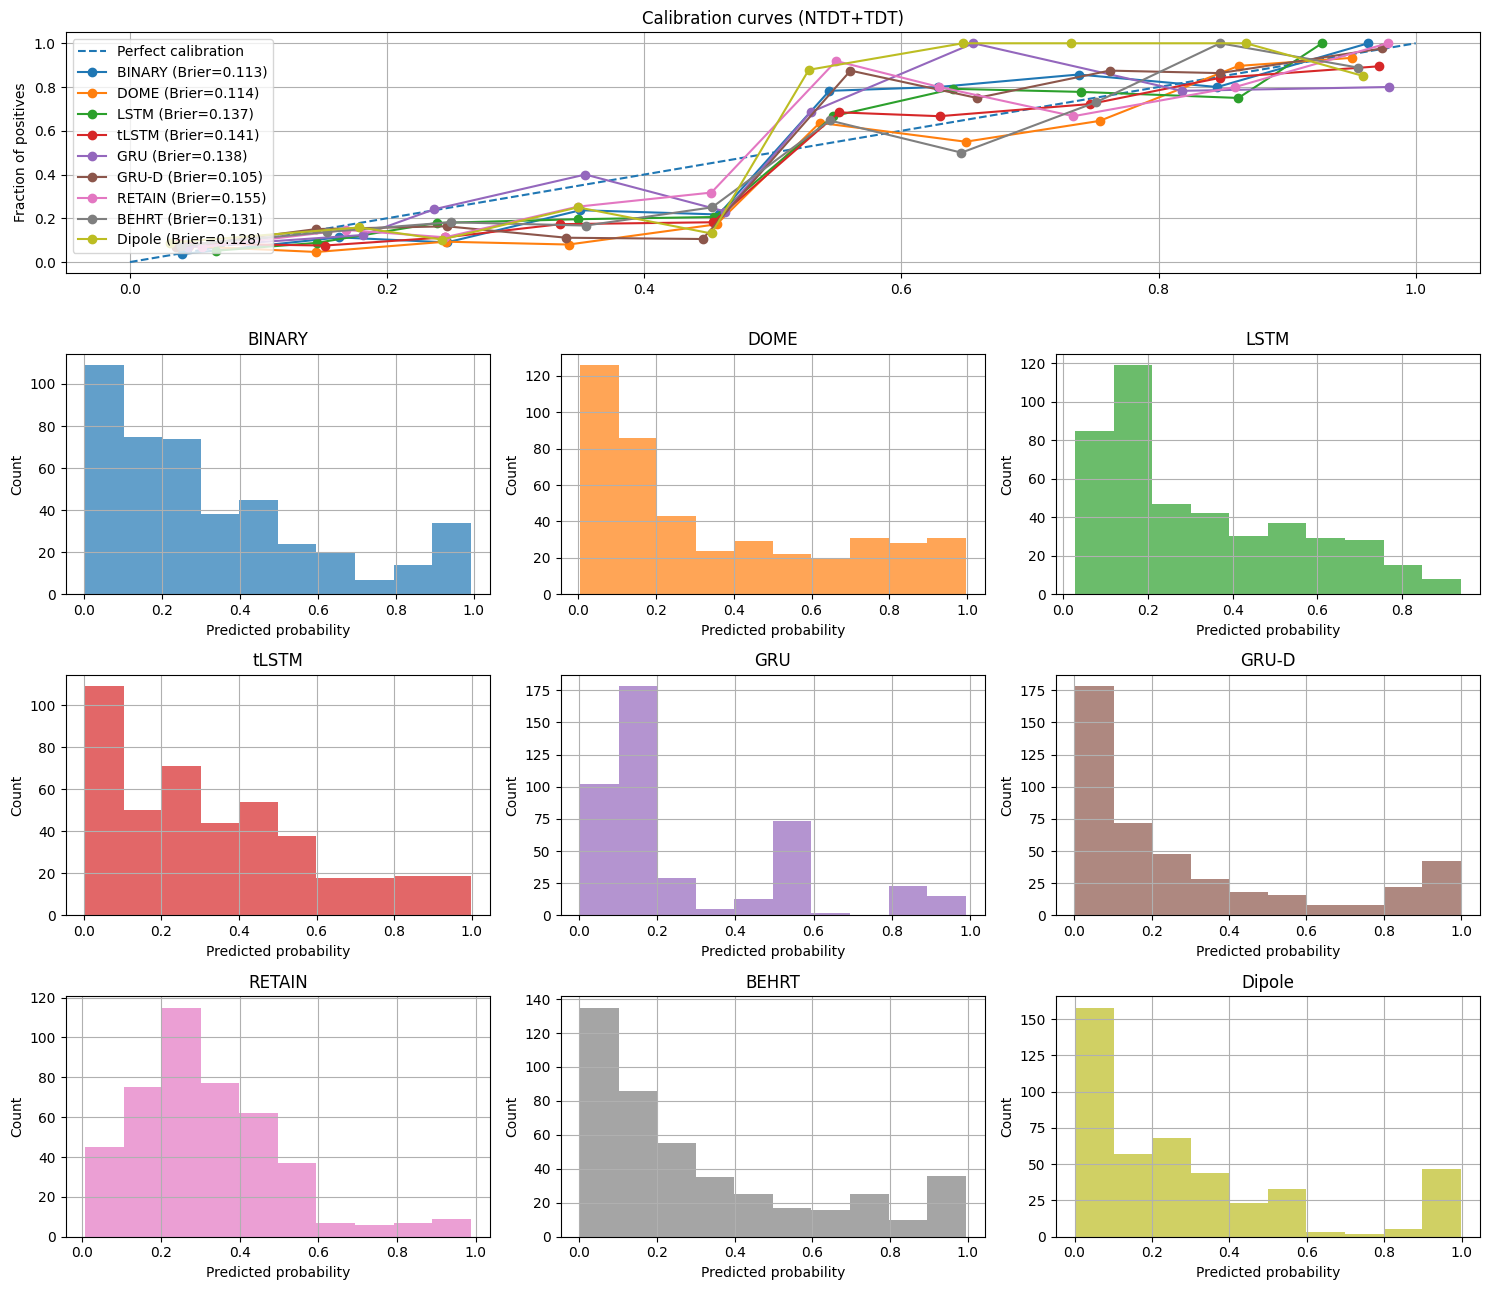

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
from sklearn.metrics import brier_score_loss

def plot_calibration_with_hist_grid(prob_pred, prob_true, all_runs, n_bins=10, n_cols=3, title="Calibration curves"):

    methods = list(prob_pred.keys())
    n_models = len(methods)
    n_rows = ceil(n_models / n_cols)

    # 🎨 colori consistenti
    cmap = plt.get_cmap("tab10")
    colors = {m: cmap(i) for i, m in enumerate(methods)}

    fig = plt.figure(figsize=(5 * n_cols, 4 + 3 * n_rows))
    gs = fig.add_gridspec(n_rows + 1, n_cols)

    # =========================
    # CALIBRATION CURVE
    # =========================
    ax_cal = fig.add_subplot(gs[0, :])
    ax_cal.plot([0, 1], [0, 1], '--', label='Perfect calibration')

    for i, m in enumerate(methods):
        x = prob_pred[m]
        y = prob_true[m]
        y_true_oof, y_prob_oof = all_runs[m]
        brier = brier_score_loss(y_true_oof, y_prob_oof)

        color = colors[m]

        ax_cal.plot(
            x, y,
            marker='o',
            color=color,
            label=f"{m} (Brier={brier:.3f})"
        )

    ax_cal.set_title(title)
    ax_cal.set_ylabel("Fraction of positives")
    ax_cal.legend(loc="upper left")
    ax_cal.grid(True)

    # =========================
    # HISTOGRAM GRID
    # =========================
    for i, m in enumerate(methods):
        row = i // n_cols + 1
        col = i % n_cols

        ax = fig.add_subplot(gs[row, col])

        y_true_oof, y_prob_oof = all_runs[m]
        color = colors[m]

        ax.hist(
            y_prob_oof,
            bins=n_bins,
            color=color,
            alpha=0.7
        )

        ax.set_title(m)
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Count")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_calibration_with_hist_grid(prob_pred, prob_true, 
                                all_runs, n_bins=10, n_cols=3, 
                                title=f"Calibration curves ({groupname})")

### Draw caliration curve

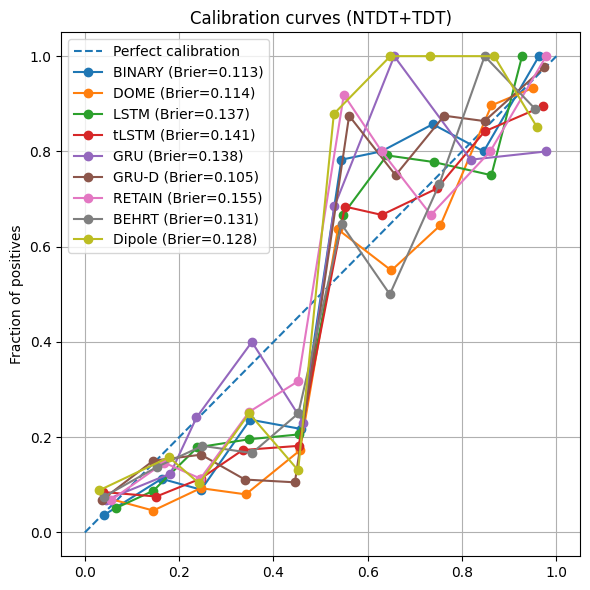

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
from sklearn.metrics import brier_score_loss

def plot_calibration(prob_pred, prob_true, all_runs, title="Calibration curves"):

    methods = list(prob_pred.keys())
    n_models = len(methods)

    # 🎨 colori consistenti
    cmap = plt.get_cmap("tab10")
    colors = {m: cmap(i) for i, m in enumerate(methods)}

    # Crea figura e asse
    fig, ax_cal = plt.subplots(figsize=(6, 6))
    
    # =========================
    # CALIBRATION CURVE
    # =========================
    ax_cal.plot([0, 1], [0, 1], '--', label='Perfect calibration')

    for i, m in enumerate(methods):
        x = prob_pred[m]
        y = prob_true[m]
        y_true_oof, y_prob_oof = all_runs[m]
        brier = brier_score_loss(y_true_oof, y_prob_oof)

        color = colors[m]

        ax_cal.plot(
            x, y,
            marker='o',
            color=color,
            label=f"{m} (Brier={brier:.3f})"
        )

    ax_cal.set_title(title)
    ax_cal.set_ylabel("Fraction of positives")
    ax_cal.legend(loc="upper left")
    ax_cal.grid(True)

    plt.tight_layout()
    plt.show()

plot_calibration(prob_pred, prob_true, 
                                all_runs,  
                                title=f"Calibration curves ({groupname})")